In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import recall_score, precision_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [2]:
data = pd.read_csv("Customer churn kaggle data.csv")

In [3]:
data = data.drop('customerID', axis = 1)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors = "coerce")

In [4]:
x = data.drop('Churn', axis = 1)
y = data['Churn'].map({"Yes": 1, "No": 0})

In [5]:
x['tenure_group'] = pd.cut(x['tenure'], bins = [0, 12, 24, 48, 72], labels = [0,1,2,3])

In [6]:
x['monthly_total_ratio'] = x['MonthlyCharges']/(x['TotalCharges'] + 1)

In [7]:
# The skewness of TotalCharges was 0.9 so we are going to transform it
x['TotalCharges'] = np.sqrt(x['TotalCharges'])

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [9]:
num_cols = x_train.select_dtypes(include = ['int64', 'float64']).columns
cat_cols = x_train.select_dtypes(include = 'object').columns

## 🛠️ 5. Pipeline Code

In [10]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = "mean")),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer([
    ('nums', num_pipeline, num_cols),
    ('cats', cat_pipeline, cat_cols)
])

In [12]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter = 1000, class_weight = 'balanced'))
])

In [13]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

In [37]:
grid = GridSearchCV(pipeline, param_grid, cv = 5, scoring = "recall", n_jobs = -1)

In [39]:
grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('nums',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'monthly_total_ratio'],
      dtype='object')),
                                                                        ('cats',
                                                                         Pipeline(steps=[('imputer',
                                             

In [40]:
best_model = grid.best_estimator_

In [41]:
y_prob = best_model.predict_proba(x_test)[:,1]

## 📊 3. Threshold Results

In [51]:
results = []

for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_prob>=t).astype(int)

    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    results.append((t, rec, prec))

df_results = pd.DataFrame(results, columns = ["Threshold", "Recall", "Precision"])
print(df_results)


   Threshold    Recall  Precision
0        0.2  0.967914   0.387580
1        0.3  0.922460   0.432331
2        0.4  0.866310   0.467532
3        0.5  0.799465   0.503367


## 📊 1. Confusion Matrix

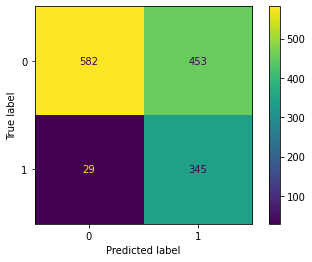

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred1 = (y_prob>=0.3).astype(int)
cm = confusion_matrix(y_test, y_pred1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## ⚙️ 2. GridSearch Output

In [44]:
print("Best Parameters:", grid.best_params_)
print("Best Score(Recall):", grid.best_score_)

Best Parameters: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best Score(Recall): 0.8080267558528428


## 📈 4. Final Output

In [53]:
y_pred1 = (y_prob>=0.3).astype(int)
print("Final Model Performance:")
print("Recall:", recall_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))

Final Model Performance:
Recall: 0.9224598930481284
Precision: 0.4323308270676692
